# Task 1:  Linear Regression & Logistic Regression 

# Logistic Regression (Salary Prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("D:/ML Internship/LinearRegression.csv")
df

,years_experience,salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.7,57189
9,4.0,63218


In [3]:
print(df.head())

   years_experience  salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891


In [4]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [5]:
x

,years_experience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.7
9,4.0


In [6]:
y

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      57189
9      63218
10     67938
11     75000
12     83088
13     91738
14    101302
15    113812
16    121872
17    122391
Name: salary, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=37)

In [8]:
x_train

,years_experience
14,7.0
0,1.1
13,6.0
2,1.5
9,4.0
3,2.0
10,4.5
6,3.0
5,2.9
17,10.0


In [9]:
x_test

,years_experience
1,1.3
8,3.7
7,3.2
4,2.2


In [10]:
y_train

14    101302
0      39343
13     91738
2      37731
9      63218
3      43525
10     67938
6      60150
5      56642
17    122391
16    121872
12     83088
11     75000
15    113812
Name: salary, dtype: int64

In [11]:
y_test

1    46205
8    57189
7    54445
4    39891
Name: salary, dtype: int64

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10485.71]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['years_experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.493e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [13]:
y_pred=model.predict(x_test)
y_pred

array([38559.48765619, 63725.20334336, 58482.34590854, 47996.63103888])

In [14]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 45794307.41719737


In [15]:
print("RMSE:",np.sqrt(mse))

RMSE: 6767.149135137881


In [16]:
print("R-squared:",r2_score(y_test, y_pred))

R-squared: 0.01910728090391489


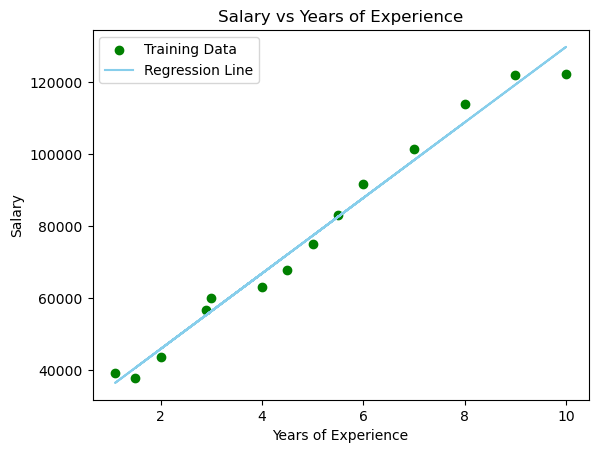

In [18]:
plt.scatter(x_train,y_train,color="green",label="Training Data")
plt.plot(x_train,model.predict(x_train),color="skyblue",label="Regression Line")
plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()